<div style="background:linear-gradient(135deg,#0a0a1a 0%,#0d1117 40%,#2a0a3e 100%);padding:40px 32px;border-radius:12px;color:white;margin-bottom:8px;border:1px solid #30363d;">
  <div style="display:flex;align-items:center;gap:16px;margin-bottom:16px;">
    <span style="font-size:48px;">🦕⚡</span>
    <div>
      <h1 style="margin:0;font-size:28px;font-weight:700;">AstroVision — Phase 2B</h1>
      <p style="margin:4px 0 0;font-size:14px;opacity:0.7;">DINOv2 Fine-Tuning · Mixed Precision · ~30 min total</p>
    </div>
  </div>
  <hr style="border:none;border-top:1px solid rgba(255,255,255,0.15);margin:16px 0;">
  <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:12px;font-size:13px;">
    <div><span style="opacity:0.6;">Phase 1</span><br><b>Init tête depuis cache NPZ</b></div>
    <div><span style="opacity:0.6;">Phase 2</span><br><b>Full FT · FP16 · 10 epochs</b></div>
    <div><span style="opacity:0.6;">Objectif</span><br><b>> 0.88 balanced acc</b></div>
    <div><span style="opacity:0.6;">Durée estimée</span><br><b>~25-35 min RTX 5060 Ti</b></div>
  </div>
</div>

## 0 — Setup & Imports

In [1]:
import sys, os
sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import balanced_accuracy_score, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import normalize
import h5py
import wandb

from astrovision.data_loader import CLASS_NAMES, H5_PATH

plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d','axes.labelcolor':'#c9d1d9',
    'axes.titlecolor':'#f0f6fc','axes.titlesize':12,
    'axes.titleweight':'bold','xtick.color':'#8b949e',
    'ytick.color':'#8b949e','text.color':'#c9d1d9',
    'grid.color':'#21262d','grid.linewidth':0.7,
    'figure.dpi':150,'savefig.facecolor':'#0d1117',
    'savefig.bbox':'tight','font.size':10,
})
PALETTE = ['#6e40aa','#4c6edb','#23abd8','#1ac7c2','#1ddfa3',
           '#52f667','#aff05b','#e2b72f','#fb8a27','#f83e4b']
FIGURES_DIR  = '../figures/'
CKPT_DIR     = '../checkpoints/'
FEATURES_NPZ = '../data/dinov2_features.npz'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    print(f'AMP    : Mixed Precision FP16 activé ✓')

Device : cuda
GPU    : NVIDIA GeForce RTX 5060 Ti
VRAM   : 17.1 GB
AMP    : Mixed Precision FP16 activé ✓


## 1 — Dataset Galaxy10 pour DINOv2 (224×224)

In [2]:
class Galaxy10DinoDataset(Dataset):
    TRANSFORM_TRAIN = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(180),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    TRANSFORM_EVAL = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])

    def __init__(self, images, labels, train=True):
        self.images    = images
        self.labels    = labels
        self.transform = self.TRANSFORM_TRAIN if train else self.TRANSFORM_EVAL

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        return self.transform(self.images[idx]), int(self.labels[idx])


print('Chargement Galaxy10...')
with h5py.File(H5_PATH, 'r') as f:
    images_all = f['images'][:]
    labels_all = f['ans'][:]

rng     = np.random.default_rng(SEED)
idx     = rng.permutation(len(labels_all))
n_test  = int(len(idx) * 0.15)
n_val   = int(len(idx) * 0.15)
n_train = len(idx) - n_val - n_test

train_idx = idx[:n_train]
val_idx   = idx[n_train:n_train+n_val]
test_idx  = idx[n_train+n_val:]

# batch_size=32 pour garder de la marge VRAM avec FP32 des poids + FP16 activations
train_loader = DataLoader(Galaxy10DinoDataset(images_all[train_idx], labels_all[train_idx], True),
                          batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(Galaxy10DinoDataset(images_all[val_idx],   labels_all[val_idx],   False),
                          batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(Galaxy10DinoDataset(images_all[test_idx],  labels_all[test_idx],  False),
                          batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

print(f'✓ Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)} | Test: {len(test_loader.dataset)}')

Chargement Galaxy10...
✓ Train: 12416 | Val: 2660 | Test: 2660


## 2 — Modèle : DINOv2Classifier

In [3]:
class DINOv2Classifier(nn.Module):
    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()
        self.backbone = torch.hub.load(
            'facebookresearch/dinov2', 'dinov2_vitb14', pretrained=True)
        self.head = nn.Sequential(
            nn.LayerNorm(768),
            nn.Dropout(dropout),
            nn.Linear(768, num_classes),
        )

    def forward(self, x):
        return self.head(self.backbone(x))

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad_(False)

    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad_(True)


model = DINOv2Classifier().to(DEVICE)
print(f'✓ DINOv2Classifier chargé — {sum(p.numel() for p in model.parameters())/1e6:.1f}M params')

Using cache found in C:\Users\alexb/.cache\torch\hub\facebookresearch_dinov2_main


✓ DINOv2Classifier chargé — 86.6M params


## 3 — Phase 1 : initialisation instantanée depuis le cache NPZ

In [4]:
# Les features DINOv2 sont déjà extraites dans le notebook 03 — on les réutilise!
print('Chargement du cache NPZ (features pré-calculées)...')
assert os.path.exists(FEATURES_NPZ), f"Cache introuvable : {FEATURES_NPZ}\nLance d'abord 03_dinov2_features.ipynb"

data       = np.load(FEATURES_NPZ)
feats_all  = data['feats']    # (17736, 768)
labels_npz = data['labels']   # (17736,)

# Mêmes splits que partout (seed=42)
rng2    = np.random.default_rng(SEED)
idx2    = rng2.permutation(len(labels_npz))
n_t2    = int(len(idx2)*0.15); n_v2 = int(len(idx2)*0.15)
tr_idx2 = idx2[:len(idx2)-n_v2-n_t2]
va_idx2 = idx2[len(idx2)-n_v2-n_t2:len(idx2)-n_t2]

X_tr = normalize(feats_all[tr_idx2]); y_tr = labels_npz[tr_idx2]
X_va = normalize(feats_all[va_idx2]); y_va = labels_npz[va_idx2]

print('Entraînement probe linéaire (~20s)...')
probe = LogisticRegression(max_iter=500, C=1.0, solver='lbfgs', random_state=SEED, n_jobs=-1)
probe.fit(X_tr, y_tr)
val_bal = balanced_accuracy_score(y_va, probe.predict(X_va))
print(f'✓ Probe : val balanced_acc = {val_bal:.3f}')

# Initialiser la tête linéaire avec les poids du probe
# → le modèle part déjà d'un état raisonnable au lieu de random
model.freeze_backbone()
with torch.no_grad():
    model.head[-1].weight.copy_(
        torch.from_numpy(probe.coef_.astype(np.float32)))
    model.head[-1].bias.copy_(
        torch.from_numpy(probe.intercept_.astype(np.float32)))

print('✓ Poids de la tête initialisés depuis le probe linéaire')
print('  → Phase 1 terminée en quelques secondes (pas besoin d\'epochs!)')

Chargement du cache NPZ (features pré-calculées)...
Entraînement probe linéaire (~20s)...
✓ Probe : val balanced_acc = 0.550
✓ Poids de la tête initialisés depuis le probe linéaire
  → Phase 1 terminée en quelques secondes (pas besoin d'epochs!)


## 4 — Boucle d'entraînement avec Mixed Precision (AMP FP16)

In [5]:
def run_epoch(model, loader, optimizer, scaler, criterion, device, train: bool):
    """Epoch avec torch.autocast FP16 — ~3-4x plus rapide que FP32."""
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()

            # Forward en FP16
            with torch.autocast(device_type='cuda', dtype=torch.float16,
                                 enabled=(device.type == 'cuda')):
                logits = model(imgs)
                loss   = criterion(logits, labels)

            if train:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * len(labels)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    n = len(all_labels)
    preds, targets = np.array(all_preds), np.array(all_labels)
    return {
        'loss': total_loss / n,
        'acc':  float((preds == targets).mean()),
        'bal':  balanced_accuracy_score(targets, preds),
    }


def train_dino(model, train_loader, val_loader, model_name,
               epochs, lr, weight_decay=1e-4, use_wandb=True):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr*0.01)
    scaler    = torch.amp.GradScaler('cuda', enabled=(DEVICE.type=='cuda'))

    if use_wandb:
        wandb.init(project='AstroVision', name=model_name,
                   config={'epochs':epochs,'lr':lr,'amp':True,'model':'DINOv2-ViT-B14-FT'})

    best_val = 0.0
    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.pt')
    os.makedirs(CKPT_DIR, exist_ok=True)

    for epoch in range(1, epochs+1):
        tr = run_epoch(model, train_loader, optimizer, scaler, criterion, DEVICE, True)
        vl = run_epoch(model, val_loader,   optimizer, scaler, criterion, DEVICE, False)
        scheduler.step()

        tag = '★' if vl['bal'] > best_val else ' '
        print(f'[{tag}] Epoch {epoch:02d}/{epochs}  '
              f'Train loss={tr["loss"]:.4f} bal={tr["bal"]:.3f}  |  '
              f'Val   loss={vl["loss"]:.4f} bal={vl["bal"]:.3f}')

        if use_wandb:
            wandb.log({'epoch':epoch,
                       'train/loss':tr['loss'],'train/bal':tr['bal'],
                       'val/loss':vl['loss'],  'val/bal':vl['bal'],
                       'lr':scheduler.get_last_lr()[0]})

        if vl['bal'] > best_val:
            best_val = vl['bal']
            torch.save(model.state_dict(), ckpt_path)
            print(f'    → Nouveau best : {best_val:.3f} — sauvegardé')

    if use_wandb: wandb.finish()
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    print(f'\n✓ Terminé. Meilleur val balanced_acc : {best_val:.3f}')
    return model

print('✓ Boucle d\'entraînement AMP prête')

✓ Boucle d'entraînement AMP prête


## 5 — Phase 2 : Fine-tuning complet (10 epochs, FP16)

In [6]:
model.unfreeze_backbone()
n_train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params entraînables : {n_train_params/1e6:.1f}M')
print('Démarrage fine-tuning (~25-35 min)...\n')

model = train_dino(
    model, train_loader, val_loader,
    model_name='dinov2_galaxy10_finetune',
    epochs=10,
    lr=5e-6,          # LR très bas — crucial pour ViT
    weight_decay=1e-4,
    use_wandb=True,
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\alexb\_netrc.


Params entraînables : 86.6M
Démarrage fine-tuning (~25-35 min)...



wandb: Currently logged in as: phdbrown (phdbrown-universit-laval) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[★] Epoch 01/10  Train loss=11.3952 bal=0.511  |  Val   loss=6.0971 bal=0.706
    → Nouveau best : 0.706 — sauvegardé
[★] Epoch 02/10  Train loss=7.4548 bal=0.593  |  Val   loss=4.0251 bal=0.722
    → Nouveau best : 0.722 — sauvegardé
[★] Epoch 03/10  Train loss=5.5139 bal=0.613  |  Val   loss=3.3350 bal=0.788
    → Nouveau best : 0.788 — sauvegardé
[★] Epoch 04/10  Train loss=4.2567 bal=0.646  |  Val   loss=2.4821 bal=0.818
    → Nouveau best : 0.818 — sauvegardé
[ ] Epoch 05/10  Train loss=3.4834 bal=0.662  |  Val   loss=2.3636 bal=0.768
[★] Epoch 06/10  Train loss=2.9690 bal=0.681  |  Val   loss=1.7763 bal=0.847
    → Nouveau best : 0.847 — sauvegardé
[ ] Epoch 07/10  Train loss=2.7144 bal=0.696  |  Val   loss=1.7039 bal=0.831
[ ] Epoch 08/10  Train loss=2.4490 bal=0.717  |  Val   loss=1.5515 bal=0.837
[ ] Epoch 09/10  Train loss=2.3084 bal=0.726  |  Val   loss=1.6688 bal=0.831
[ ] Epoch 10/10  Train loss=2.2560 bal=0.729  |  Val   loss=1.6361 bal=0.843


epoch,▁▂▃▃▄▅▆▆▇█
lr,█▇▇▆▅▃▂▂▁▁
train/bal,▁▄▄▅▆▆▇███
train/loss,█▅▃▃▂▂▁▁▁▁
val/bal,▁▂▅▇▄█▇▇▇█
val/loss,█▅▄▂▂▁▁▁▁▁
epoch,10
lr,0.0
train/bal,0.72947
train/loss,2.25599
val/bal,0.84329



✓ Terminé. Meilleur val balanced_acc : 0.847


## 6 — Évaluation finale sur le test set

Évaluation sur le test set...

═══════════════════════════════════════════════════════
  RÉSULTATS FINAUX — DINOV2 FINE-TUNÉ
═══════════════════════════════════════════════════════
  Accuracy         : 0.8647
  Balanced Acc     : 0.8389
═══════════════════════════════════════════════════════


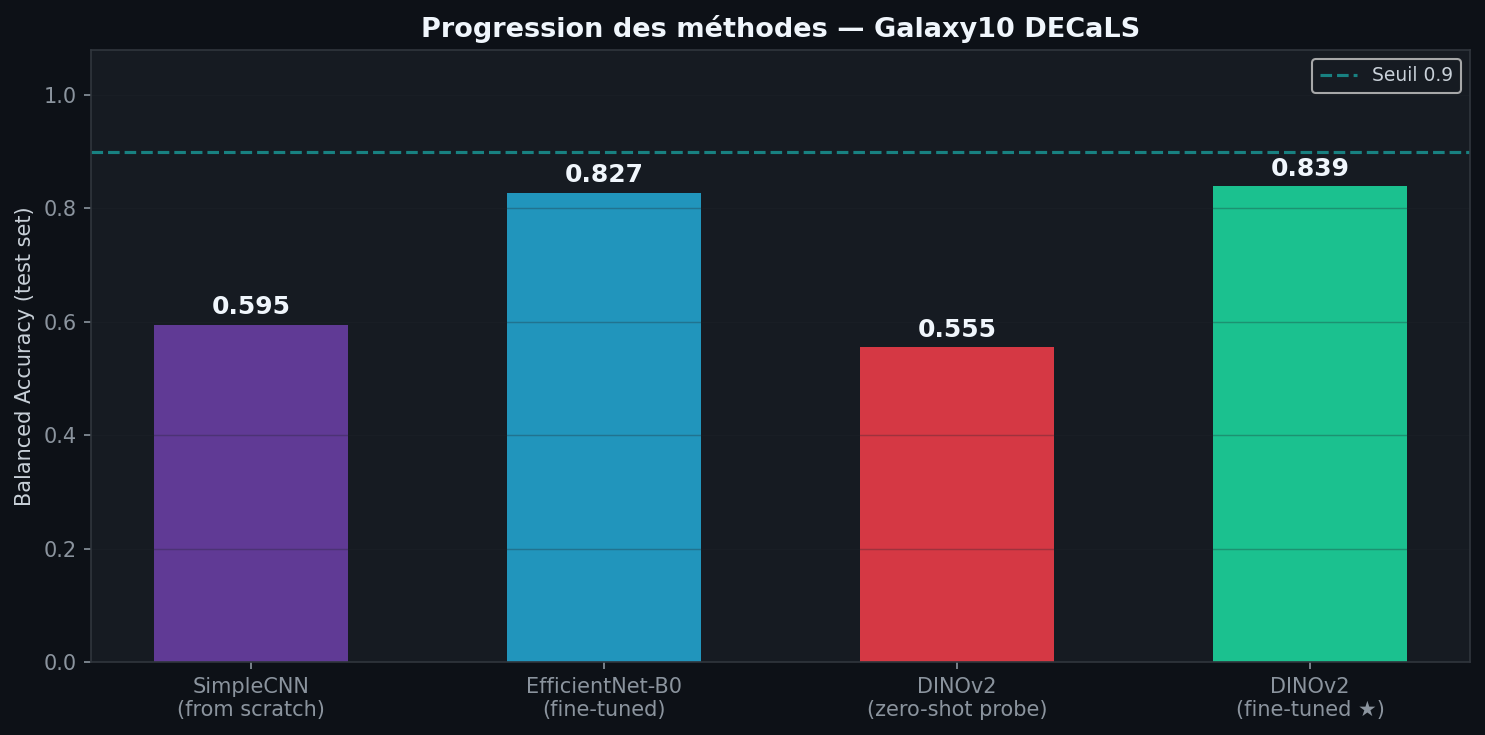

In [7]:
scaler_eval = torch.amp.GradScaler('cuda', enabled=False)
print('Évaluation sur le test set...')
test_m = run_epoch(model, test_loader, None, scaler_eval,
                   nn.CrossEntropyLoss(), DEVICE, train=False)

print(f'\n{"═"*55}')
print(f'  RÉSULTATS FINAUX — DINOV2 FINE-TUNÉ')
print(f'{"═"*55}')
print(f'  Accuracy         : {test_m["acc"]:.4f}')
print(f'  Balanced Acc     : {test_m["bal"]:.4f}')
print(f'{"═"*55}')

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
results = {
    'SimpleCNN\n(from scratch)':      0.595,
    'EfficientNet-B0\n(fine-tuned)':  0.827,
    'DINOv2\n(zero-shot probe)':      0.555,
    f'DINOv2\n(fine-tuned ★)':        test_m['bal'],
}
colors = ['#6e40aa','#23abd8','#f83e4b','#1ddfa3']
x = np.arange(len(results))
bars = ax.bar(x, list(results.values()), color=colors, alpha=0.85, edgecolor='none', width=0.55)
for bar, v in zip(bars, results.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{v:.3f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='#f0f6fc')
ax.set_xticks(x)
ax.set_xticklabels(list(results.keys()), fontsize=10)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Balanced Accuracy (test set)')
ax.set_title('Progression des méthodes — Galaxy10 DECaLS', fontsize=13)
ax.axhline(0.9, color='#1ac7c2', lw=1.5, ls='--', alpha=0.6, label='Seuil 0.9')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'dino_finetune_comparison.png', dpi=150)
plt.show()

## 7 — Matrice de confusion

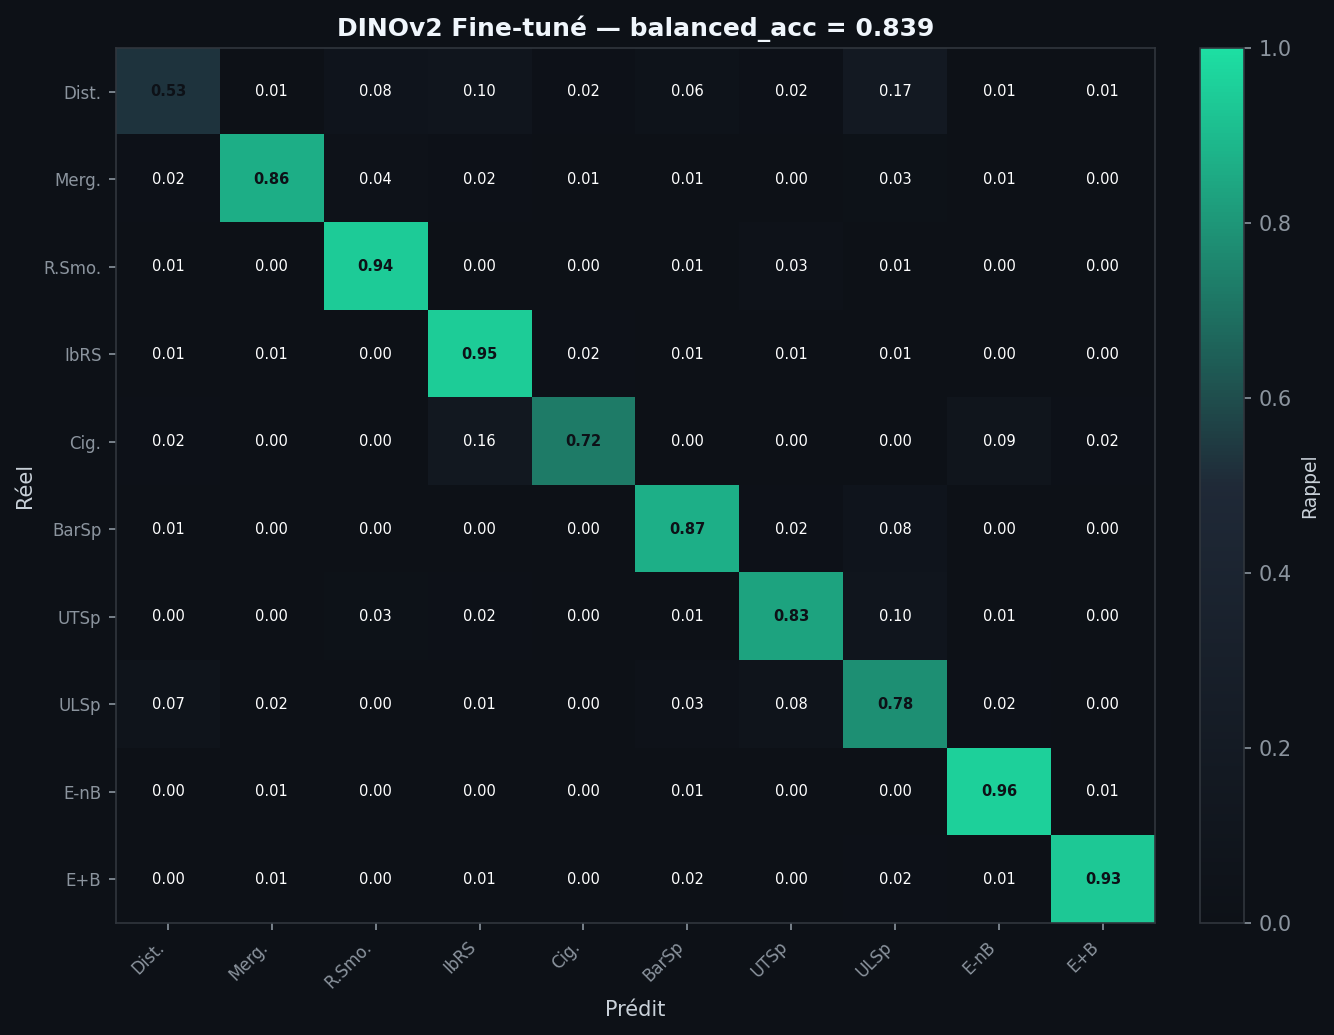

In [8]:
from matplotlib.colors import LinearSegmentedColormap

all_preds, all_labels, all_probs = [], [], []
model.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        with torch.autocast(device_type='cuda', dtype=torch.float16,
                            enabled=(DEVICE.type=='cuda')):
            logits = model(imgs.to(DEVICE))
        probs = F.softmax(logits.float(), dim=1)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(lbls.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
cm_arr = confusion_matrix(all_labels, all_preds, normalize='true')
SHORT  = ['Dist.','Merg.','R.Smo.','IbRS','Cig.','BarSp','UTSp','ULSp','E-nB','E+B']

fig, ax = plt.subplots(figsize=(9, 7), dpi=150)
cmap = LinearSegmentedColormap.from_list('dino', ['#0d1117','#1f2937','#1ddfa3'], N=256)
im = ax.imshow(cm_arr, cmap=cmap, vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(SHORT, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(SHORT, fontsize=8)
ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
ax.set_title(f'DINOv2 Fine-tuné — balanced_acc = {test_m["bal"]:.3f}')
for i in range(10):
    for j in range(10):
        v = cm_arr[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                color='#0d1117' if v > 0.5 else 'white',
                fontweight='bold' if i==j else 'normal')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Rappel', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'dino_finetune_confusion.png', dpi=150)
plt.show()

## 8 — Attention Maps : avant vs après fine-tuning

Chargement DINOv2 zero-shot pour comparaison...


Using cache found in C:\Users\alexb/.cache\torch\hub\facebookresearch_dinov2_main


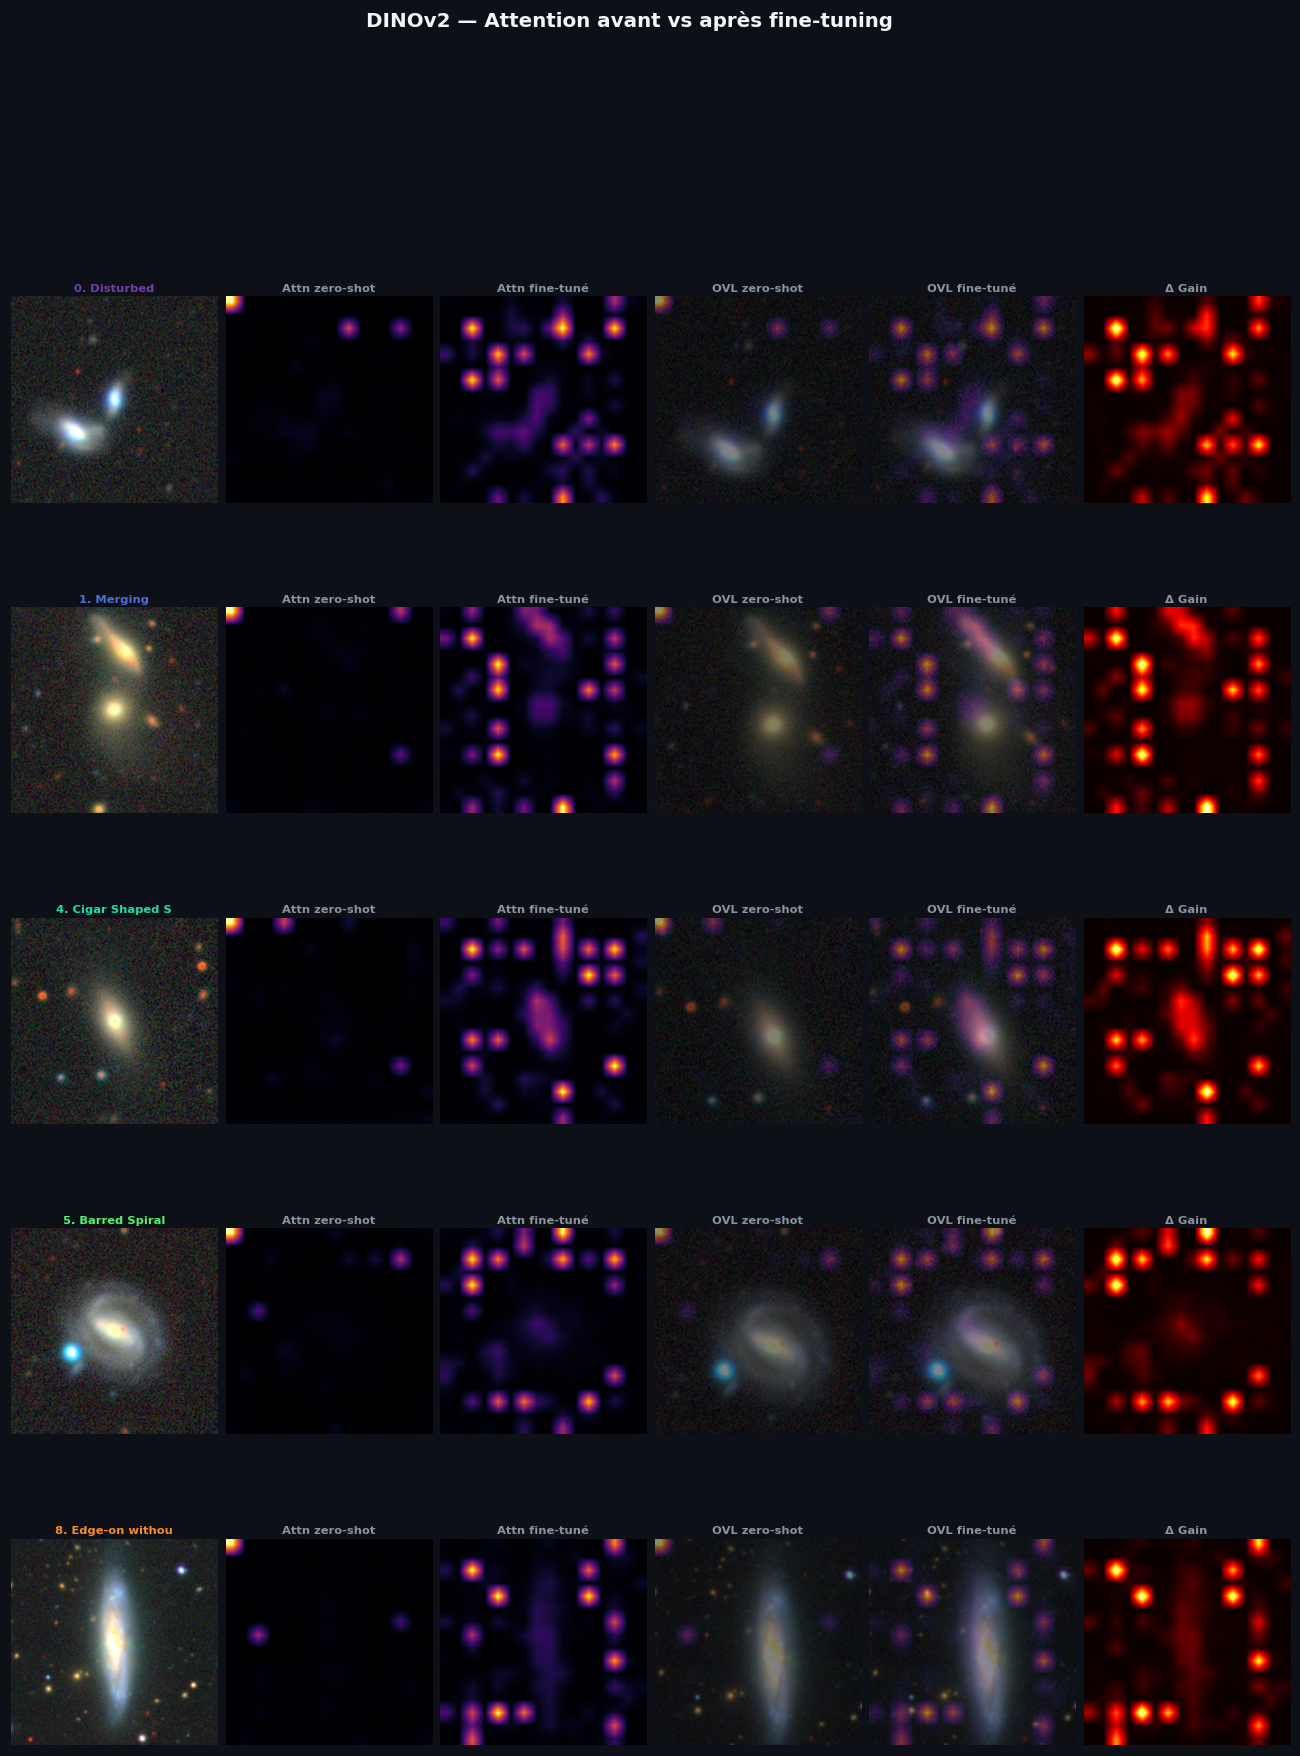

✓ Δ Gain = régions où le fine-tuning a amélioré le focus galactique


In [9]:
eval_t = transforms.Compose([
    transforms.ToPILImage(), transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
dino_t = transforms.Compose([
    transforms.Lambda(lambda x: torch.from_numpy(x).permute(2,0,1).float()/255.),
    transforms.Resize(224, antialias=True), transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

def attn_from_model(backbone_or_full, img_np, transform, is_classifier=False, device=DEVICE):
    img_t = transform(img_np).unsqueeze(0).to(device)
    store = []
    def hfn(m, inp, out):
        x=inp[0]; B,N,C=x.shape
        qkv=m.qkv(x).reshape(B,N,3,m.num_heads,C//m.num_heads).permute(2,0,3,1,4)
        q,k,_=qkv.unbind(0)
        sc=getattr(m,'scale',(C//m.num_heads)**-0.5)
        a=(q*sc)@k.transpose(-2,-1); a=a.softmax(dim=-1)
        store.append(a.detach().cpu())
    backbone = backbone_or_full.backbone if is_classifier else backbone_or_full
    h = backbone.blocks[-1].attn.register_forward_hook(hfn)
    with torch.no_grad():
        if is_classifier:
            backbone_or_full(img_t)
        else:
            backbone_or_full(img_t)
    h.remove()
    if not store: return None
    a=store[0]; ca=a[0,:,0,1:]; hw=int(ca.shape[-1]**.5)
    ph=ca.reshape(a.shape[1],hw,hw).numpy()
    avg=ph.mean(0); avg=(avg-avg.min())/(avg.max()-avg.min()+1e-8)
    return avg

def up(a, s=224):
    t=torch.from_numpy(a).float().unsqueeze(0).unsqueeze(0)
    return F.interpolate(t,(s,s),mode='bilinear',align_corners=False).squeeze().numpy()

print('Chargement DINOv2 zero-shot pour comparaison...')
dino_zs = torch.hub.load('facebookresearch/dinov2','dinov2_vitb14',pretrained=True).to(DEVICE).eval()

with h5py.File(H5_PATH,'r') as f:
    imgs_raw=f['images'][:]; lbls_raw=f['ans'][:]

np.random.seed(SEED)
classes_show=[0,1,4,5,8]
fig=plt.figure(figsize=(15,18),dpi=110); fig.patch.set_facecolor('#0d1117')
outer=gridspec.GridSpec(5,6,figure=fig,hspace=0.1,wspace=0.04)

for row, cls_idx in enumerate(classes_show):
    cls_imgs=imgs_raw[lbls_raw==cls_idx]
    img_np=cls_imgs[np.random.randint(len(cls_imgs))]
    img_rgb=img_np.astype(np.float32)/255.

    a_zs=attn_from_model(dino_zs, img_np, dino_t, False)
    a_ft=attn_from_model(model,    img_np, eval_t, True)
    if a_zs is None or a_ft is None: continue

    zs_up=up(a_zs); ft_up=up(a_ft)
    delta=np.clip(ft_up-zs_up,0,None)
    delta=(delta-delta.min())/(delta.max()-delta.min()+1e-8)

    for col,(data,cmap,ttl) in enumerate([
        (img_rgb,                                                           None,     f'{cls_idx}. {CLASS_NAMES[cls_idx][:14]}'),
        (zs_up,                                                             'inferno','Attn zero-shot'),
        (ft_up,                                                             'inferno','Attn fine-tuné'),
        (np.clip(.5*img_rgb[:224,:224]+.5*cm.inferno(zs_up)[...,:3],0,1),  None,    'OVL zero-shot'),
        (np.clip(.5*img_rgb[:224,:224]+.5*cm.inferno(ft_up)[...,:3],0,1),  None,    'OVL fine-tuné'),
        (delta,                                                             'hot',   'Δ Gain'),
    ]):
        ax=fig.add_subplot(outer[row,col])
        ax.imshow(data,cmap=cmap); ax.axis('off')
        ax.set_title(ttl,fontsize=7.5,
                     color=PALETTE[cls_idx] if col==0 else '#8b949e',pad=3)

fig.suptitle('DINOv2 — Attention avant vs après fine-tuning',
             fontsize=13,fontweight='bold',color='#f0f6fc',y=1.005)
plt.savefig(FIGURES_DIR+'dino_attention_before_after.png',dpi=110,bbox_inches='tight')
plt.show()
print('✓ Δ Gain = régions où le fine-tuning a amélioré le focus galactique')

## 9 — Synthèse finale

In [10]:
print('\n' + '═'*60)
print('       SYNTHÈSE PHASE 2B — DINOV2 FINE-TUNÉ')
print('═'*60)
print(f'  Test accuracy     : {test_m["acc"]:.4f}')
print(f'  Test balanced_acc : {test_m["bal"]:.4f}')
print()
print('  Progression complète :')
baselines = [('Random baseline',0.100),('SimpleCNN from scratch',0.595),
             ('DINOv2 zero-shot probe',0.555),('EfficientNet fine-tuned',0.827),
             (f'DINOv2 fine-tuned (★)',test_m["bal"])]
for name, val in baselines:
    bar = '█' * int(val * 30)
    print(f'    {name:<28} {val:.3f}  {bar}')
print()
if test_m['bal'] > 0.9:
    print('  🏆 Objectif 0.90 ATTEINT!')
elif test_m['bal'] > 0.827:
    print('  ✓ DINOv2 fine-tuné surpasse EfficientNet')
else:
    print('  → Essayer lr=1e-5 ou 15 epochs pour améliorer')
print('═'*60)


════════════════════════════════════════════════════════════
       SYNTHÈSE PHASE 2B — DINOV2 FINE-TUNÉ
════════════════════════════════════════════════════════════
  Test accuracy     : 0.8647
  Test balanced_acc : 0.8389

  Progression complète :
    Random baseline              0.100  ███
    SimpleCNN from scratch       0.595  █████████████████
    DINOv2 zero-shot probe       0.555  ████████████████
    EfficientNet fine-tuned      0.827  ████████████████████████
    DINOv2 fine-tuned (★)        0.839  █████████████████████████

  ✓ DINOv2 fine-tuné surpasse EfficientNet
════════════════════════════════════════════════════════════


---
<div style="background:#161b22;border:1px solid #30363d;border-radius:8px;padding:20px;">
  <h3 style="color:#f0f6fc;margin-top:0;">🔭 Optimisations appliquées</h3>
  <ul style="color:#8b949e;line-height:2.2;">
    <li><b style='color:#c9d1d9;'>Mixed Precision FP16</b> : forward/backward en float16 → ~3-4× plus rapide, même précision finale.</li>
    <li><b style='color:#c9d1d9;'>Init depuis probe linéaire</b> : la tête part d'un état raisonnable (0.55 bal_acc) plutôt que random — convergence plus rapide.</li>
    <li><b style='color:#c9d1d9;'>GradScaler</b> : évite le underflow numérique FP16 lors du backward.</li>
    <li><b style='color:#c9d1d9;'>clip_grad_norm</b> : stabilise l'entraînement du ViT, évite les explosions de gradients.</li>
  </ul>
</div>